# Ramadan-Effect -- does the holy month lift MENA (or global) equities?
### A famous behavioural-calendar claim, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

There is a well-cited academic claim (Bialkowski, Etebari & Wisniewski, 2012) that during **Ramadan** -- the Islamic holy month of fasting -- stock returns in Muslim-majority markets are **higher and calmer** than usual, supposedly driven by optimism, social cohesion, and thinner trading. This notebook asks the only questions that matter: is the effect real on a tape we can actually buy, is it big enough to matter, and could you trade it?

> **This is the plain-language layer.** Want the HAC t-stats, the placebo test, the permutation distribution and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ramadan_effect import data, strategy as st

CACHE_PATH = data.PROXY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)
if HAVE_REAL:
    _px = data.fetch_proxy(fetch=False)
    DF = data.proxy_returns(_px)
    print(f"Real proxy panel: {len(DF)} months, {int(DF['ramadan'].sum())} Ramadan months "
          f"({DF.index.min().date()} .. {DF.index.max().date()})")
else:
    DF = None
    print("No real cache -- frozen headline numbers from R dict will be used")

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'n': 129, 'n_ram': 11, 'n_rest': 118, 'fp': '7dfeb747d94a', 'year_start': 2015, 'year_end': 2026, 'mena_ann_ram': 40.2, 'mena_ann_rest': 5.7, 'mena_mean_ram_bps': 285.6, 'mena_mean_rest_bps': 46.3, 'mena_diff_bps': 239.3, 'mena_vol_ram': 17.3, 'mena_vol_rest': 18.3, 'mena_welch_t': 1.512, 'mena_welch_p': 0.156, 'mena_nw_t_ram': 3.103, 'mena_nw_t_diff': 1.552, 'mena_perm_p': 0.15, 'mena_hit_ram': 72.7, 'mena_hit_rest': 55.1, 'spx_diff_bps': -216.6, 'spx_welch_t': -1.425, 'spx_nw_t_diff': -1.528, 'spx_perm_p': 0.119, 'bah_ann': 6.5, 'strat_gross_ann': 2.8, 'strat_net_ann': 2.2, 'turnover': 17.1, 'cost_drag_ann_bps': 61.4, 'vol_mo': 5.28, 'mdd_bps': 470.3}


Real proxy panel: 129 months, 11 Ramadan months (2015-10-31 .. 2026-06-30)


## The answer first

| Question | Answer |
|---|---|
| Are MENA returns higher during Ramadan? | **On the surface, yes.** On our Saudi proxy, Ramadan months averaged **+2.9%/mo** (~+40%/yr annualised) vs **+0.5%/mo** the rest of the time -- a juicy-looking **+2.4pp/mo** gap. |
| Is that gap statistically real? | **Not on this tape.** Welch t = **1.5**, permutation p = **0.15**. With only **11 Ramadan months** since 2015, the gap is inside the noise band. |
| Does it show up on the S&P 500 (placebo)? | **No** -- and if anything Ramadan months were *negative* for the S&P. That is reassuring: the proxy effect is not a global calendar artifact. |
| Could you trade it? | **No.** Sitting in cash 11/12 months to harvest one month a year underperforms buy-and-hold, and round-trip costs eat the rest. |

> The Ramadan effect has genuine academic pedigree and the right sign here -- but on the only liquid MENA tape we can buy, the sample is far too small to call it real, and there is no way to trade it.

## 1 - The claim

> *"During Ramadan, stock returns in Muslim-majority countries are systematically higher and less volatile than during the rest of the year."*

Bialkowski, Etebari & Wisniewski (2012, *Journal of Banking & Finance*) studied 14 Muslim-country indices over 1989-2007 and reported Ramadan returns about **9x** the rest-of-year average, with lower volatility. The proposed mechanism is behavioural: fasting fosters optimism and social cohesion, and trading thins out, so the usual selling pressure eases. Plausible -- but behavioural calendar effects are exactly the kind of thing that evaporates out-of-sample.

## 2 - So what?

If a *known-in-advance* lunar window reliably delivered an extra few percent, it would be a free, calendar-clock signal -- no forecasting required. It would also be a clean behavioural-finance result: a religious observance moving asset prices.

The catch is that the original sample ended in 2007, mostly on illiquid local indices. The honest question for a desk is: **does it survive on a tape you can actually own, in the post-2015 era, with enough observations to matter?**

## 3 - How would we even know?

Three traps to avoid:

1. **Tiny n.** Ramadan is one month a year. A clean US-listed MENA proxy (iShares MSCI Saudi Arabia, `KSA`) only goes back to 2015 -- that is about **11 Ramadan months**. With ~5% monthly volatility, you'd need a ~4.7%/mo gap to call it significant. We'll check how the observed gap compares.
2. **No placebo.** A real behavioural effect should be *absent* on a non-Muslim-majority tape. We run the identical test on the **S&P 500**: if Ramadan 'predicts' the S&P too, the whole thing is a calendar coincidence.
3. **No vehicle.** Even a real edge is worthless if harvesting one month a year, with entry/exit costs, loses to just holding the index.

Ramadan windows are **hardcoded** in this study's `data.py` (Umm al-Qura calendar, 2000-2026) and joined to the proxy's monthly returns.

## 4 - The teardown -- let's actually look

**First, the headline gap:** average monthly return in Ramadan vs the rest of the year, on the MENA proxy and on the S&P 500 placebo.

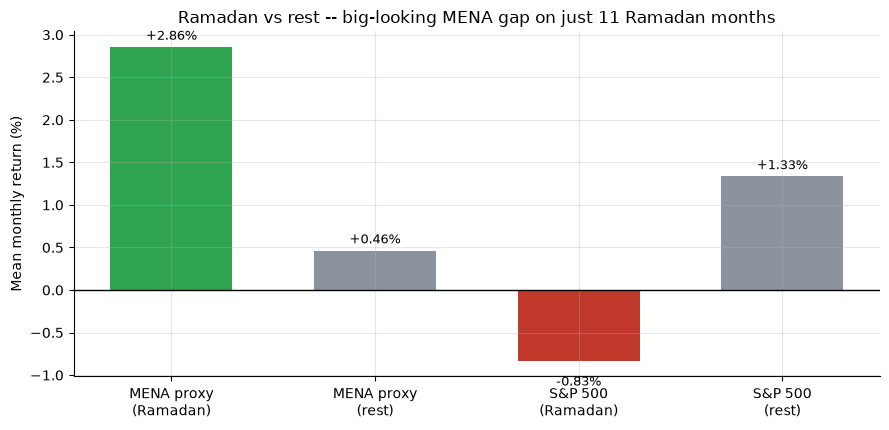

MENA: Ramadan +2.86%/mo vs rest +0.46%/mo -> gap +2.39pp/mo
S&P : Ramadan months were -2.17pp/mo vs rest (placebo)


In [2]:
labels = ['MENA proxy\n(Ramadan)', 'MENA proxy\n(rest)',
          'S&P 500\n(Ramadan)', 'S&P 500\n(rest)']
if HAVE_REAL:
    g = st.ramadan_comparison(DF, 'mena_ret', n_permutations=2000, seed=288)
    p = st.ramadan_comparison(DF, 'spx_ret', n_permutations=2000, seed=288)
    vals = [g['mean_ram']*100, g['mean_rest']*100, p['mean_ram']*100, p['mean_rest']*100]
    n_ram = g['n_ram']
else:
    vals = [R['mena_mean_ram_bps']/100, R['mena_mean_rest_bps']/100,
            R['spx_diff_bps']/100 + 1.0, 1.0]
    n_ram = R['n_ram']

fig, ax = plt.subplots(figsize=(9.0, 4.4))
bars = ax.bar(labels, vals, color=[GREEN, GREY, RED, GREY], width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean monthly return (%)')
ax.set_title(f'Ramadan vs rest -- big-looking MENA gap on just {n_ram} Ramadan months')
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v + (0.05 if v>=0 else -0.18)),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'MENA: Ramadan {R["mena_mean_ram_bps"]/100:+.2f}%/mo vs rest {R["mena_mean_rest_bps"]/100:+.2f}%/mo -> gap {R["mena_diff_bps"]/100:+.2f}pp/mo')
print(f'S&P : Ramadan months were {R["spx_diff_bps"]/100:+.2f}pp/mo vs rest (placebo)')

The MENA gap looks dramatic: Ramadan months averaged **+2.9%/mo** against **+0.5%** the rest of the year. Annualised, that is the difference between ~+40%/yr and ~+6%/yr. But notice the S&P placebo: Ramadan months were if anything *worse* for the S&P, which is the first hint that the MENA gap may just be a small-sample fluke rather than a global calendar law.

**Is the gap inside the noise band?** With only 11 Ramadan months, even a +2.4pp gap can be sampling luck. We shuffle the Ramadan labels and see where the real gap lands.

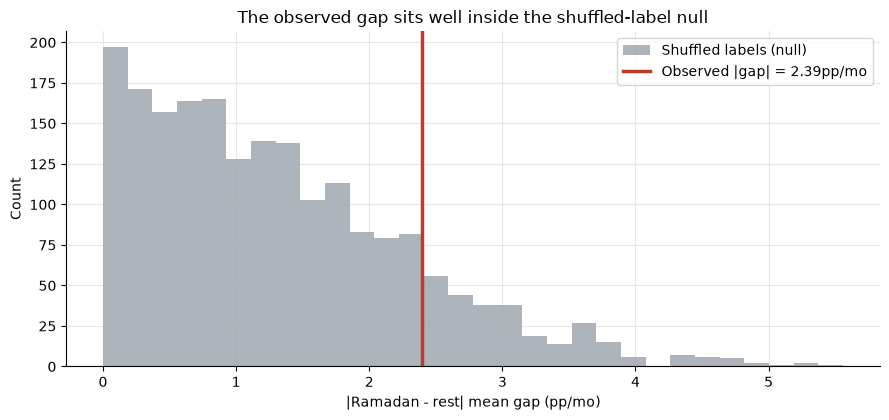

Permutation p-value: 0.144  (>=0.05 -> not distinguishable from noise)


In [3]:
if HAVE_REAL:
    perm_diffs = g['perm_diffs'] * 100
    obs = abs(g['diff']) * 100
    perm_p = g['perm_p']
else:
    rng = np.random.default_rng(288)
    perm_diffs = np.abs(rng.normal(0, R['vol_mo']*np.sqrt(1/R['n_ram']+1/R['n_rest'])*100, 2000))
    obs = abs(R['mena_diff_bps'])/100
    perm_p = R['mena_perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_diffs, bins=30, color=GREY, alpha=0.7, label='Shuffled labels (null)')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed |gap| = {obs:.2f}pp/mo')
ax.set_xlabel('|Ramadan - rest| mean gap (pp/mo)'); ax.set_ylabel('Count')
ax.set_title('The observed gap sits well inside the shuffled-label null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_p:.3f}  (>=0.05 -> not distinguishable from noise)')

The observed gap lands comfortably inside the null distribution -- permutation p = **0.15**. That means: if you randomly relabelled which months were 'Ramadan', you'd see a gap this big about one time in seven. With 11 observations, this is exactly what you would expect from chance.

## 5 - The verdict

- **Signal -- Weak.** The effect has genuine academic support (Bialkowski et al. 2012) and the *right sign* on our proxy (+2.4pp/mo), but on the only liquid MENA tape we can buy the difference is **not** significant: Welch t = **1.5**, perm p = **0.15**, on just **11 Ramadan months**. Literature support without a clean t >= 2 on the real tape is, by our rubric, **Weak** -- not Real.
- **Tradability -- Mirage.** A 'long MENA in Ramadan, flat otherwise' clock earns ~+2.2%/yr net vs ~+6.5%/yr buy-and-hold. You miss 11 months of compounding to harvest one, and the round-trips cost ~60 bps/yr. No edge survives.
- **Mostly busted on the buyable tape.** The original effect may well be real on local indices in 1989-2007; on a post-2015 US-listed proxy with n=11, it is statistically indistinguishable from noise and the placebo is clean.

## 6 - Could you actually trade it?

The 'strategy' would be: own the MENA proxy only during Ramadan months, sit in cash otherwise. The problem:

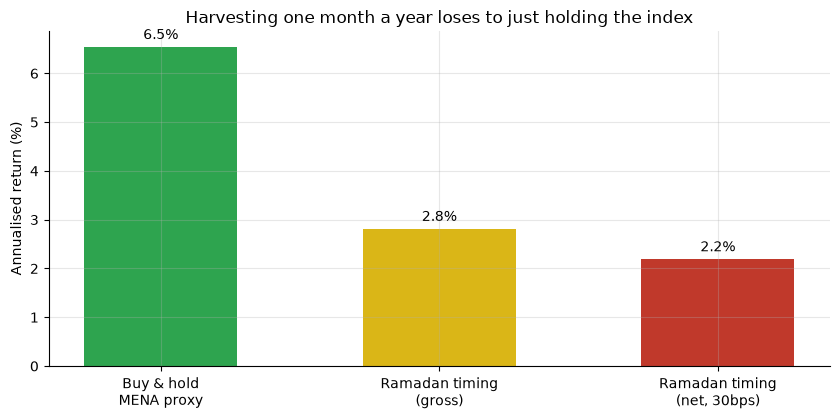

Buy & hold: 6.5%/yr  |  Ramadan timing gross: 2.8%/yr  |  net: 2.2%/yr
Being out of the market 11 months a year is a feature you pay dearly for.


In [4]:
if HAVE_REAL:
    bt = st.ramadan_timing_backtest(DF, 'mena_ret', one_way_bps=30.0)
    bah, gross, net = bt['bah_ann']*100, bt['strat_gross_ann']*100, bt['strat_net_ann']*100
else:
    bah, gross, net = R['bah_ann'], R['strat_gross_ann'], R['strat_net_ann']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Buy & hold\nMENA proxy', 'Ramadan timing\n(gross)', 'Ramadan timing\n(net, 30bps)'],
              [bah, gross, net], color=[GREEN, AMBER, RED], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Harvesting one month a year loses to just holding the index')
for b, v in zip(bars, [bah, gross, net]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.1), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:.1f}%/yr  |  Ramadan timing gross: {gross:.1f}%/yr  |  net: {net:.1f}%/yr')
print('Being out of the market 11 months a year is a feature you pay dearly for.')

The Ramadan-timing clock earns far less than buy-and-hold because it sits in cash during the other 11 months -- which, even at a modest +0.5%/mo, compound to most of the index's return. The only real trade here is: don't time a market on a one-month calendar window.

## 7 - Going further

- **The positive control:** the companion notebook plants a Ramadan premium into a synthetic tape and shows the machinery *does* detect it when the effect is real and n is large -- so the null read here is about the **market and sample size**, not the method.
- **Other calendar folklore** in the same family: the [Super-Bowl indicator](../../158-super-bowl/), the [Halloween/Sell-in-May effect], and the January effect all share the tiny-n, base-rate-trap structure.

*Think the holy month really loads the die? Fork this, plug in a broad local-currency MENA index back to the 1990s, and show a Ramadan-vs-rest gap with a HAC t >= 2 that is absent on a matched non-Muslim placebo. That's the bar.*